# MarketForecast — Foolad / TSETMC
Forecast the next observed traded session's **adjusted official closing price**.
This is retrospective research: backward adjustments use later corporate actions.
Official close (`pClosing`) and last trade (`pDrCotVal`) are different fields.
Run cells in order. A GPU is optional; CPU works. Data is frozen for five years, with a 70/15/15
chronological split. No market performance is claimed until real data and evaluation succeed.
For this experiment choose Runtime → Change runtime type → A100 GPU (when available).


In [1]:
from pathlib import Path
import subprocess, sys
REPO_URL = "https://github.com/sina-04/MarketForecast.git"
REPO_REF = "codex/tsetmc-colab"
REPO_DIR = Path("/content/MarketForecast")
if not (REPO_DIR / ".git").exists():
    subprocess.run(["git", "clone", "--branch", REPO_REF, "--single-branch", REPO_URL, str(REPO_DIR)], check=True)
COMMIT = subprocess.check_output(["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True).strip()
print("Repository commit:", COMMIT)
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True).stdout if __import__('shutil').which('nvidia-smi') else "CPU runtime")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "requirements-colab.txt")], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(REPO_DIR)], check=True)


Repository commit: 20092ecd702f793cf798b5d58cedcad9f69563de
name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB



CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--no-deps', '-e', '/content/MarketForecast'], returncode=0)

## Storage
By default mount Drive and write under `MyDrive/MarketForecast`. Complete Google's normal authorization
if requested. For a temporary run set `PERSIST_TO_DRIVE=False`, then download the archive before disconnecting.


In [2]:
PERSIST_TO_DRIVE = True
if PERSIST_TO_DRIVE:
    from google.colab import drive
    assert Path("/content/drive/MyDrive").is_dir(), "Mount Drive interactively first"
    ROOT = Path("/content/drive/MyDrive/MarketForecast")
else:
    ROOT = Path("/content/marketforecast_outputs")
ROOT.mkdir(parents=True, exist_ok=True)
from marketforecast.io import read_json, write_json
CONFIG = read_json(REPO_DIR / "configs/default.json")
write_json(ROOT / "source_commit.json", {"commit": COMMIT, "repo": REPO_URL})
print("Output root:", ROOT)


Output root: /content/drive/MyDrive/MarketForecast


## Implementation checks
Synthetic test fixtures validate behavior, not market performance.


In [3]:
subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=REPO_DIR, check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q'], returncode=0)

## Collect or validate the frozen snapshot
The first capture excludes today's Tehran date. Later runs validate and reuse the snapshot.
If this cell fails, run `marketforecast collect --root artifacts/local` locally and copy the complete
`artifacts/local/data/snapshot` directory to `ROOT/data/snapshot` in Drive. Rerun to verify checksums.
If both routes fail, stop. Do not substitute synthetic data.
For user pytse exports, import locally with `marketforecast import --unadjusted <CSV> --adjusted <CSV>`.
Copy the resulting snapshot directory to Drive, or place its portable ZIP at `ROOT/foolad_snapshot_20260926.zip`.


In [4]:
import zipfile
SNAPSHOT_ZIP = ROOT / "foolad_snapshot_20260926.zip"
if not (ROOT / "data/snapshot/manifest.json").exists() and SNAPSHOT_ZIP.exists():
    with zipfile.ZipFile(SNAPSHOT_ZIP) as archive:
        for name in archive.namelist():
            if (name != "data/" and not name.startswith("data/snapshot/")) or ".." in Path(name).parts:
                raise ValueError("Unexpected snapshot archive member")
        archive.extractall(ROOT)
from marketforecast.data import collect
SNAPSHOT, MANIFEST = collect(ROOT, CONFIG)
print(MANIFEST)
import pandas as pd
from IPython.display import display
raw = pd.read_csv(SNAPSHOT / "raw.csv")
display(raw.head(), raw.tail())


{'symbol': 'فولاد', 'company_contains': 'فولادمبارکه', 'years': 5, 'start_date': '2021-09-26', 'end_date': '2026-09-26', 'instrument_ids': ['46348559193224090'], 'isin': 'IRO1FOLD0001', 'company': 'فولاد مبارکه اصفهان', 'retrieved_at_utc': 'Not recorded by source exporter', 'imported_at_utc': '2026-09-27T04:12:33.197884+00:00', 'source': 'TSETMC via user-supplied pytse-client CSV exports', 'adapter_version': 'pytse-export-import/0.1.0', 'source_version': 'Not recorded by source exporter', 'mapping_reference': 'https://github.com/Glyphack/pytse-client', 'field_mapping': {'adjClose': 'official_close', 'close': 'last_trade', 'yesterday': 'previous_official_close', 'count': 'trade_count'}, 'completion_policy': 'Strictly before current Tehran date', 'checksums': {'adjustment_basis.csv': '093bc323027c52863eb8f8b1fe8c7ec88f410e0307003bbfa598a29838e84ce6', 'export_validation.json': '02da7cd9cbe9a7c0c2c4db216de7e8061dde7f23acb8175966124b812d8b3edc', 'raw.csv': 'bc3f1942d674818036226d213f0e6c313

,date,open,high,low,official_close,last_trade,previous_official_close,volume,value,trade_count,instrument_id
0,2021-09-26,10750.0,10750.0,10350.0,10500.0,10450.0,10550.0,48809259,512583511180,10829,46348559193224090
1,2021-09-28,10600.0,10600.0,10350.0,10440.0,10490.0,10500.0,43601832,455163241800,10422,46348559193224090
2,2021-09-29,10410.0,10660.0,10380.0,10480.0,10560.0,10440.0,61996626,649826970080,10047,46348559193224090
3,2021-10-02,10590.0,11000.0,10590.0,10900.0,10870.0,10480.0,127159011,1386646483970,15429,46348559193224090
4,2021-10-03,10870.0,11020.0,10700.0,10860.0,10890.0,10900.0,64915676,705010036710,9427,46348559193224090


,date,open,high,low,official_close,last_trade,previous_official_close,volume,value,trade_count,instrument_id
1033,2026-09-20,3210.0,3280.0,3210.0,3210.0,3220.0,3300.0,5563296448,17883948678370,56546,46348559193224090
1034,2026-09-21,3280.0,3300.0,3200.0,3290.0,3300.0,3210.0,3581143472,11785928323720,38289,46348559193224090
1035,2026-09-22,3380.0,3380.0,3200.0,3260.0,3230.0,3290.0,3705610251,12095800625600,45559,46348559193224090
1036,2026-09-23,3350.0,3350.0,3280.0,3350.0,3350.0,3260.0,2210827100,7398241941410,21174,46348559193224090
1037,2026-09-26,3390.0,3390.0,3250.0,3260.0,3250.0,3350.0,2512505604,8195077042750,31636,46348559193224090


## Audit, adjust, engineer features, and prepare sequences
Unresolved invalid traded records stop preparation after their quarantine audit is saved.
Do not edit frozen CSVs in place; corrections need a separate documented snapshot.
All window lengths and model comparisons share the same target dates.


Run: /content/drive/MyDrive/MarketForecast/runs/0fae8c8d8bf0 Audits: {'cleaning': {'raw_rows': 1038, 'clean_rows': 1037, 'quarantined_rows': 1, 'reason_counts': {'nonpositive_price': 1, 'invalid_candle': 1}, 'adjustment_safe': True, 'adjustment_basis': 'Verified complete export chain, including quarantined missing-open session', 'missing_open_sessions_excluded': 1}, 'features': {'input_rows': 1037, 'usable_rows': 1004, 'warmup_or_nonfinite_rows': 33}} Features: ['adj_open', 'adj_high', 'adj_low', 'adj_official_close', 'volume', 'return_1', 'close_lag_1', 'return_lag_1', 'close_lag_2', 'return_lag_2', 'close_lag_5', 'return_lag_5', 'sma_5', 'ema_5', 'volatility_5', 'rolling_max_5', 'rolling_min_5', 'price_to_sma_5', 'sma_10', 'ema_10', 'volatility_10', 'rolling_max_10', 'rolling_min_10', 'price_to_sma_10', 'sma_20', 'ema_20', 'volatility_20', 'rolling_max_20', 'rolling_min_20', 'price_to_sma_20', 'rsi_14', 'macd', 'macd_signal', 'macd_histogram', 'bollinger_upper', 'bollinger_lower', 'b

,date,jalali_date,adj_official_close,volume
999,2026-09-20,1405-06-29,3210.0,5563296448
1000,2026-09-21,1405-06-30,3290.0,3581143472
1001,2026-09-22,1405-06-31,3260.0,3705610251
1002,2026-09-23,1405-07-01,3350.0,2210827100
1003,2026-09-26,1405-07-04,3260.0,2512505604


train (618, 30, 48) 2022-02-07 2024-11-06
validation (132, 30, 48) 2024-11-09 2025-06-08
test (134, 30, 48) 2025-06-09 2026-09-26


<Axes: title={'center': 'Adjusted official close (rial)'}, xlabel='date'>

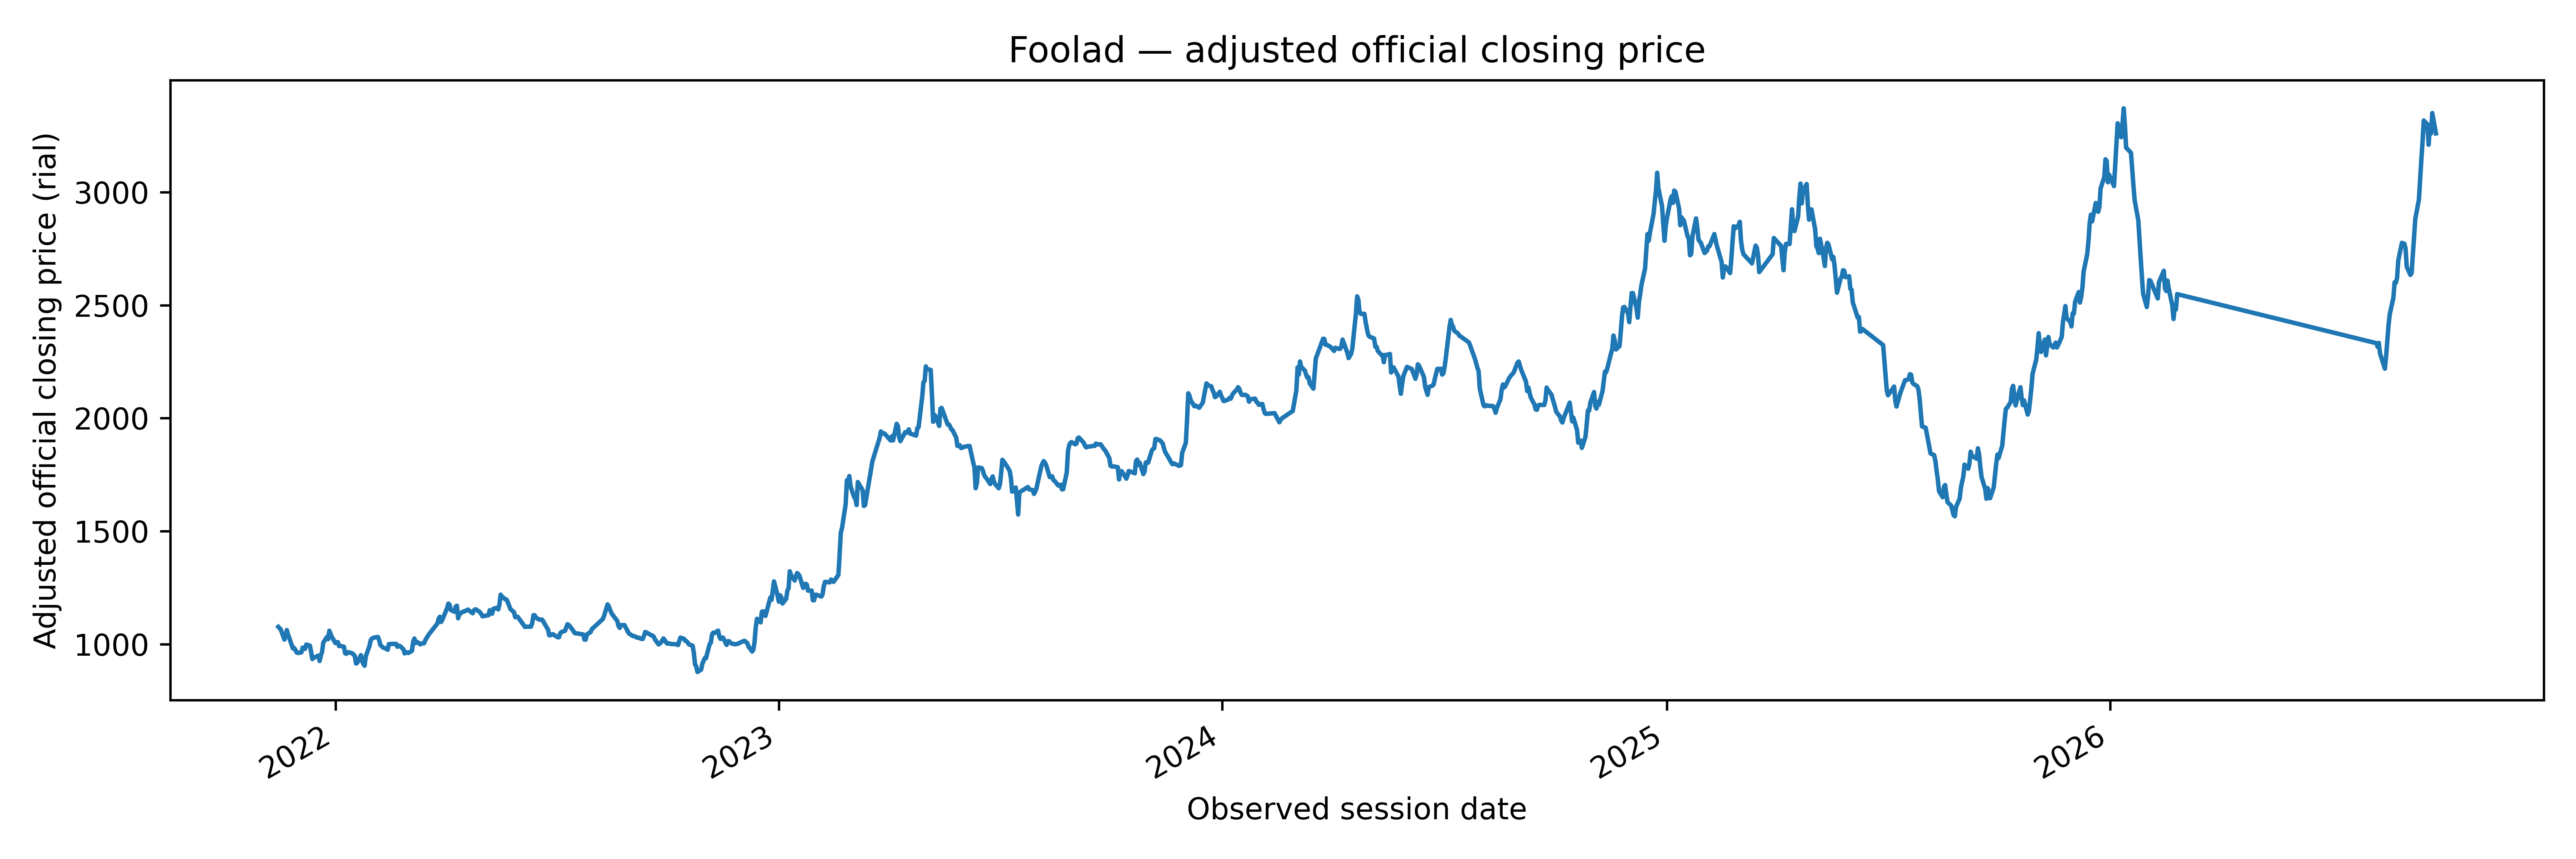

In [5]:
from marketforecast.workflow import prepare_run
OUTPUT, FRAME, FEATURES, PLAN, MANIFEST, AUDITS = prepare_run(ROOT, CONFIG)
print("Run:", OUTPUT, "Audits:", AUDITS, "Features:", FEATURES)
display(FRAME[["date", "jalali_date", "adj_official_close", "volume"]].tail())
from marketforecast.sequences import prepare
splits, _, _ = prepare(FRAME, FEATURES, CONFIG["default_sequence_length"], PLAN)
for name, split in splits.items():
    print(name, split["X"].shape, split["dates"][0], split["dates"][-1])
FRAME.plot(x="date", y="adj_official_close", figsize=(12, 4), title="Adjusted official close (rial)")


## Train, select on validation, then evaluate the sealed test period
Six candidates: lengths 10/30/60 × widths 32/64. Dropout 0.2, Adam/MSE, batch 32,
at most 100 epochs, early-stopping patience 10. Best checkpoints persist on Drive.
Completed candidates are reused; interrupted candidates restart from their seed.
Ridge is validation-selected; OHLCV ablation holds the selected architecture constant.
Do not tune parameters after inspecting test results.


In [6]:
from marketforecast.workflow import run
OUTPUT = run(ROOT, CONFIG, acquire=False)
display(pd.DataFrame(read_json(OUTPUT / "test_metrics.json")).T)


Training/validating lstm_10_32


Epoch 1/100


20/20 - 4s - 185ms/step - loss: 0.2430 - val_loss: 2.0777


Epoch 2/100


20/20 - 0s - 8ms/step - loss: 0.1771 - val_loss: 1.3239


...

Epoch 28/100


20/20 - 0s - 7ms/step - loss: 0.0193 - val_loss: 0.1321


Epoch 29/100


20/20 - 0s - 7ms/step - loss: 0.0208 - val_loss: 0.1033


,MAE,MSE,RMSE,MAPE,samples
lstm,335.574329,218155.212178,467.070886,11.755931,134.0
persistence,52.124678,3696.719818,60.800656,1.965986,134.0
ridge,187.941929,68510.729326,261.745543,6.999991,134.0
ohlcv_lstm,283.325436,152706.471207,390.776754,9.900262,134.0


## Verify saved models and reproduce predictions
Both `.keras` and required `.h5` are checked.


{'verified': True, 'predictions': 134}


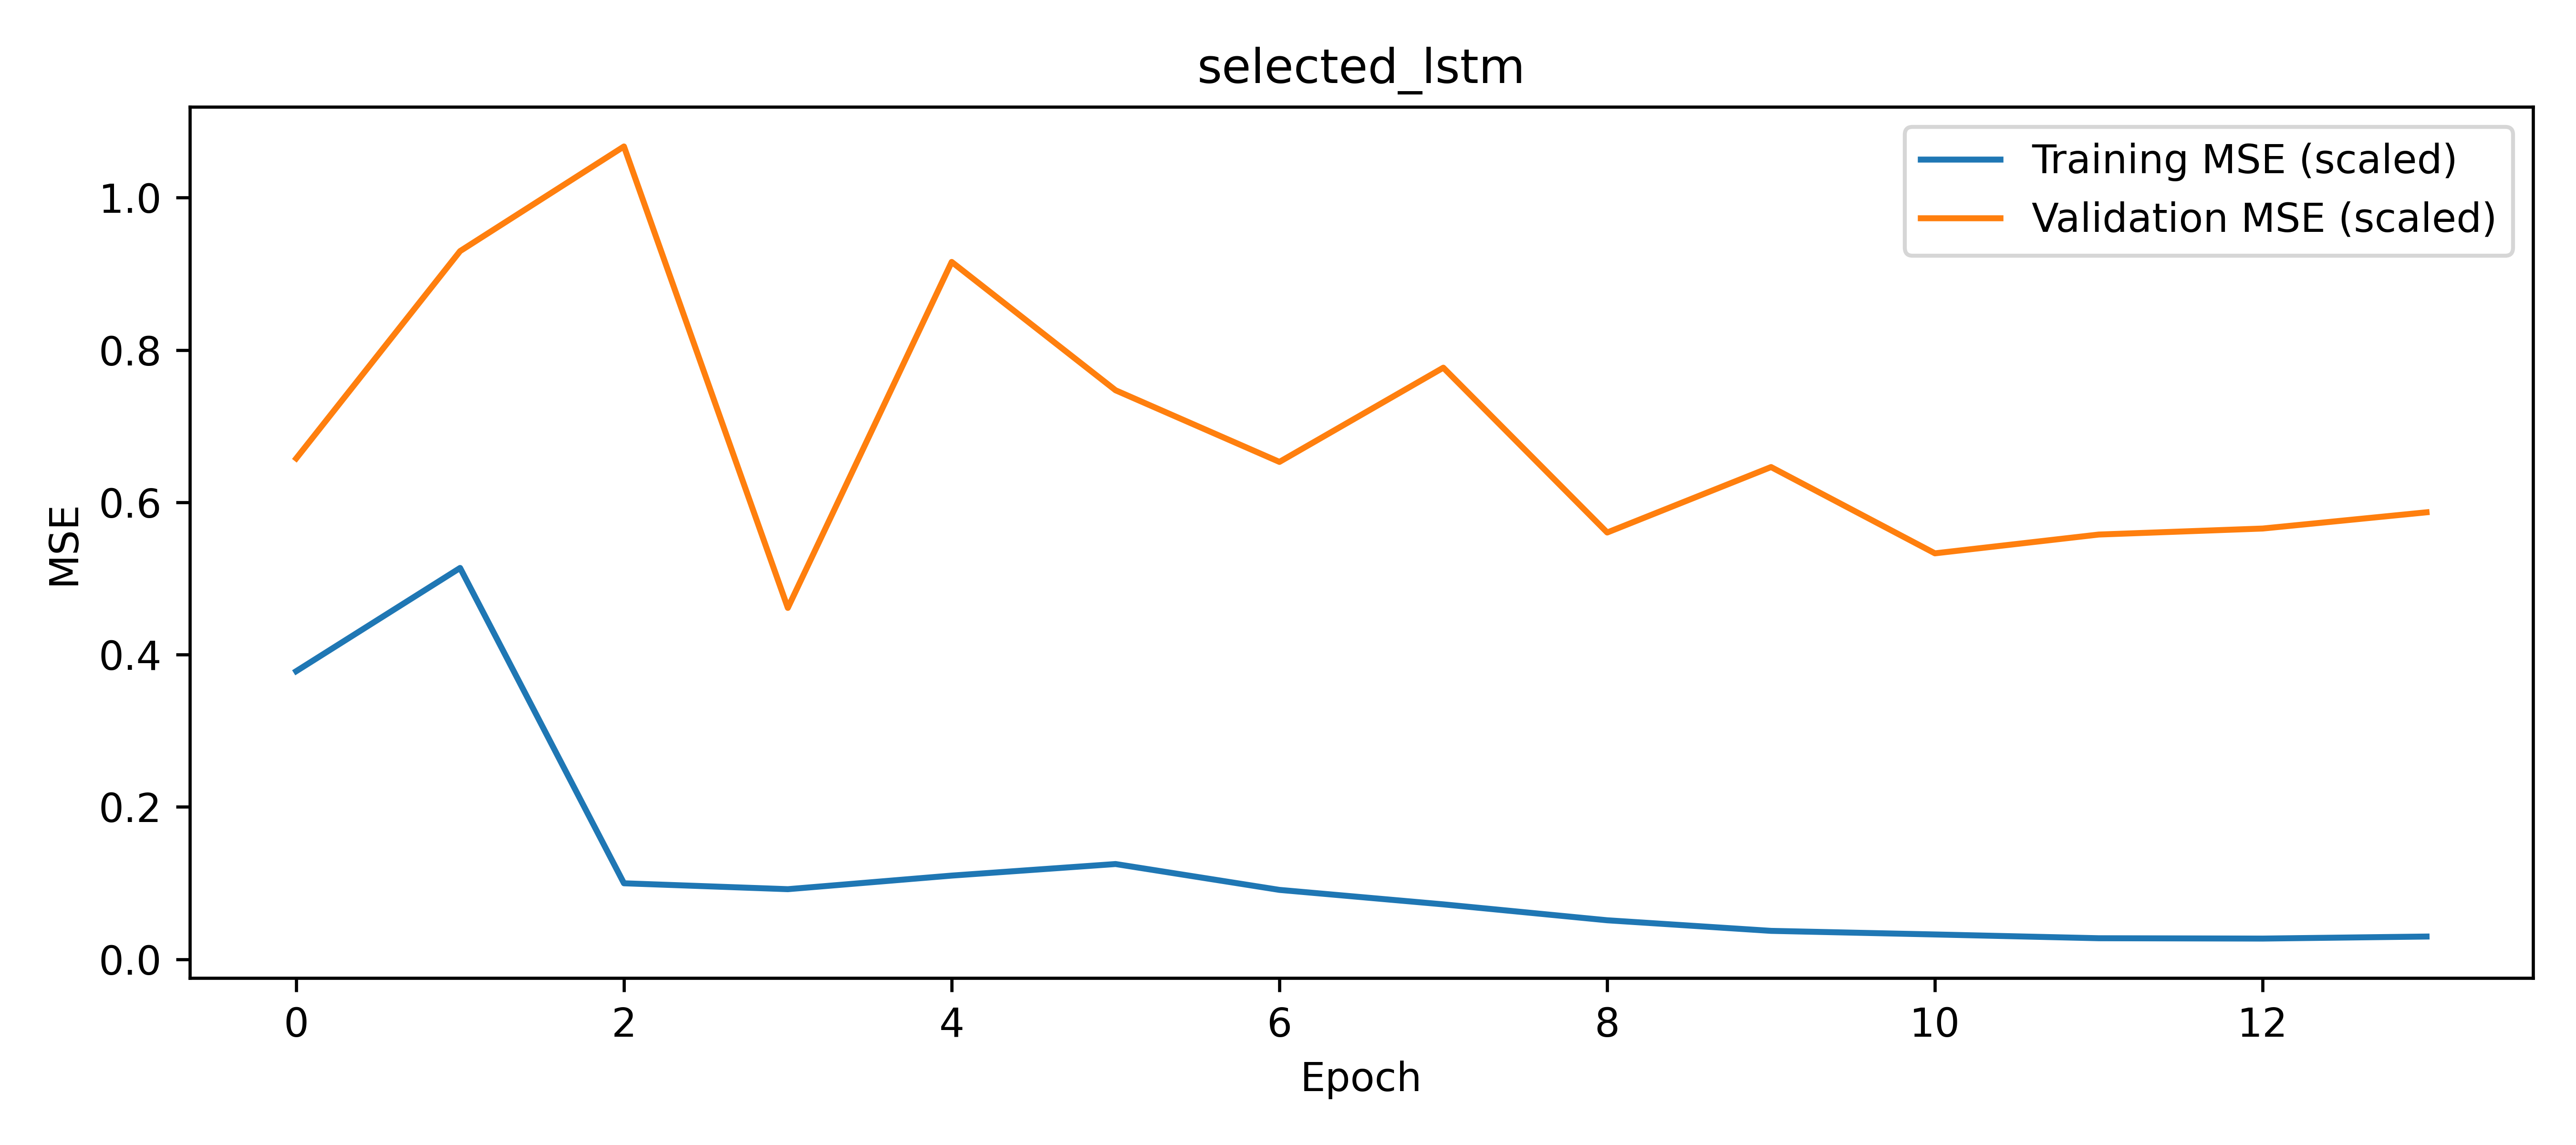

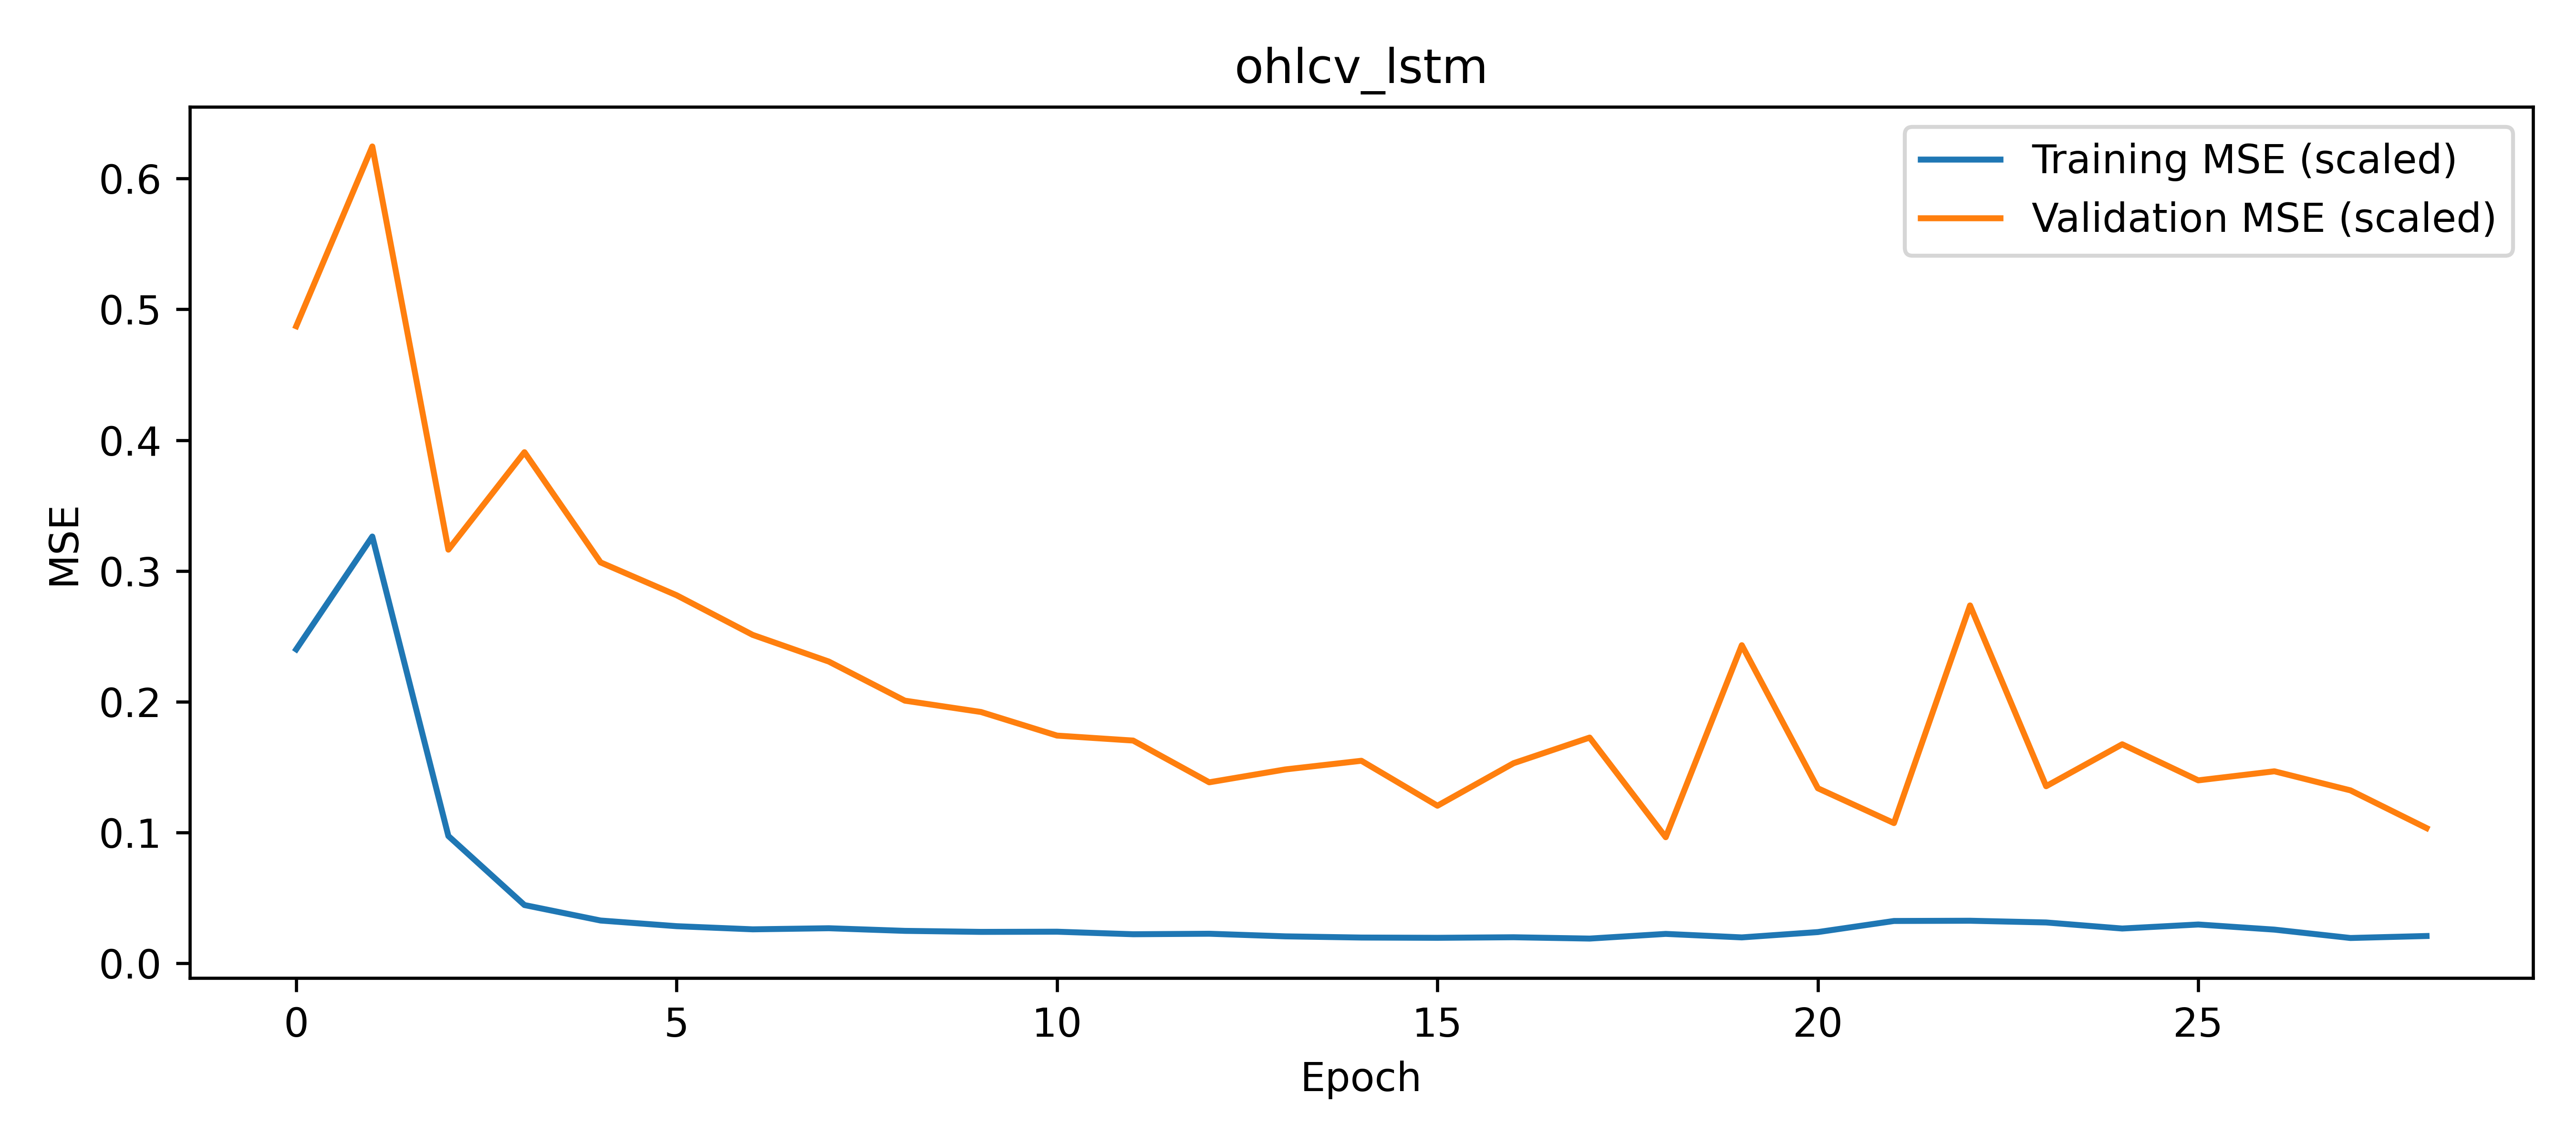

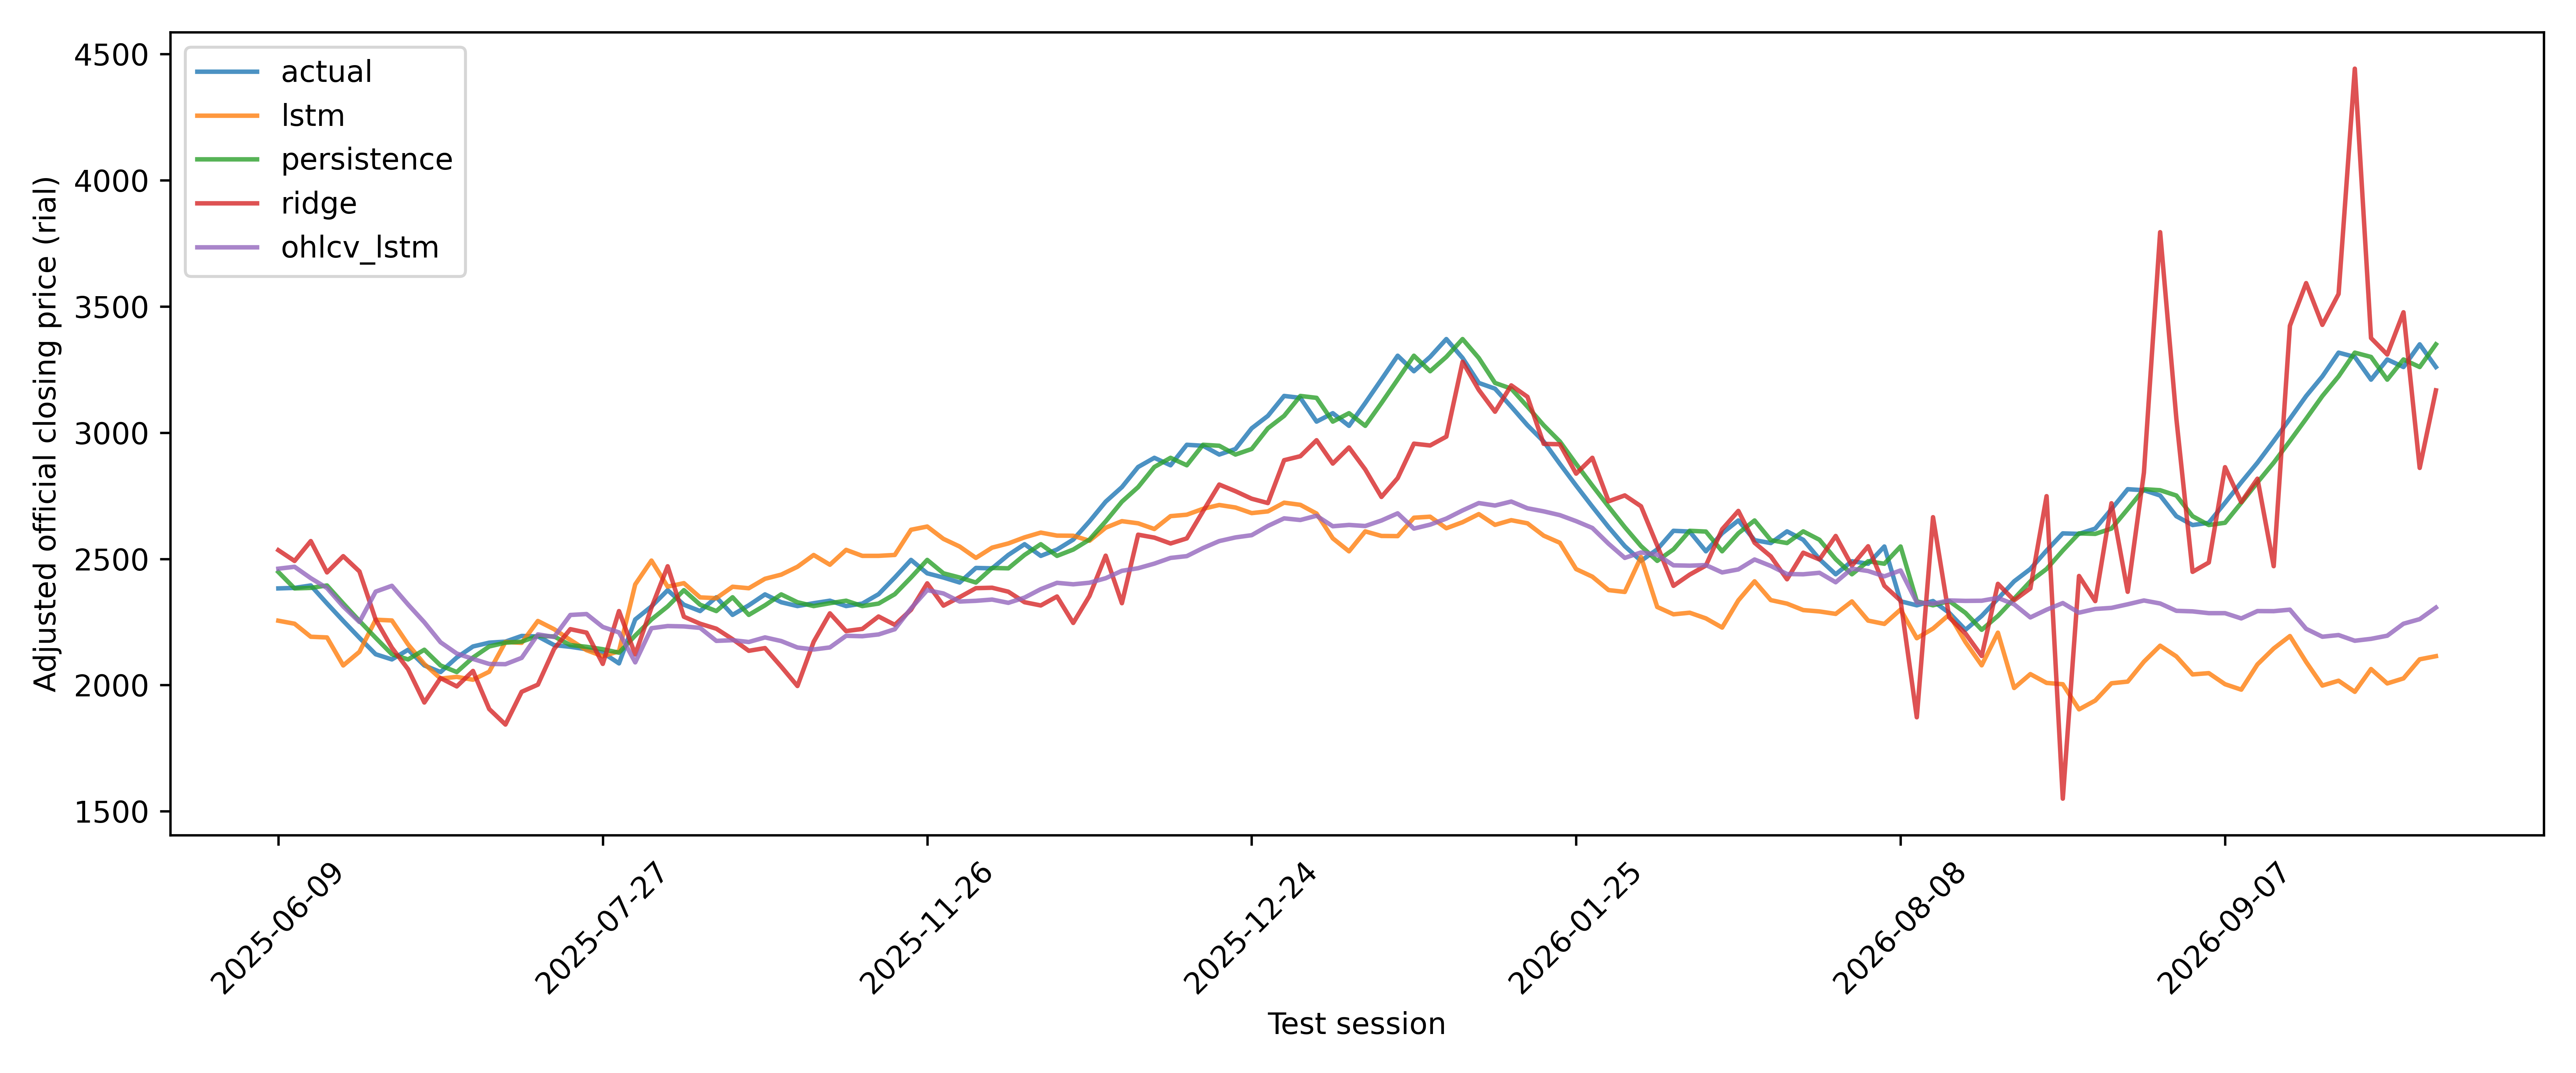

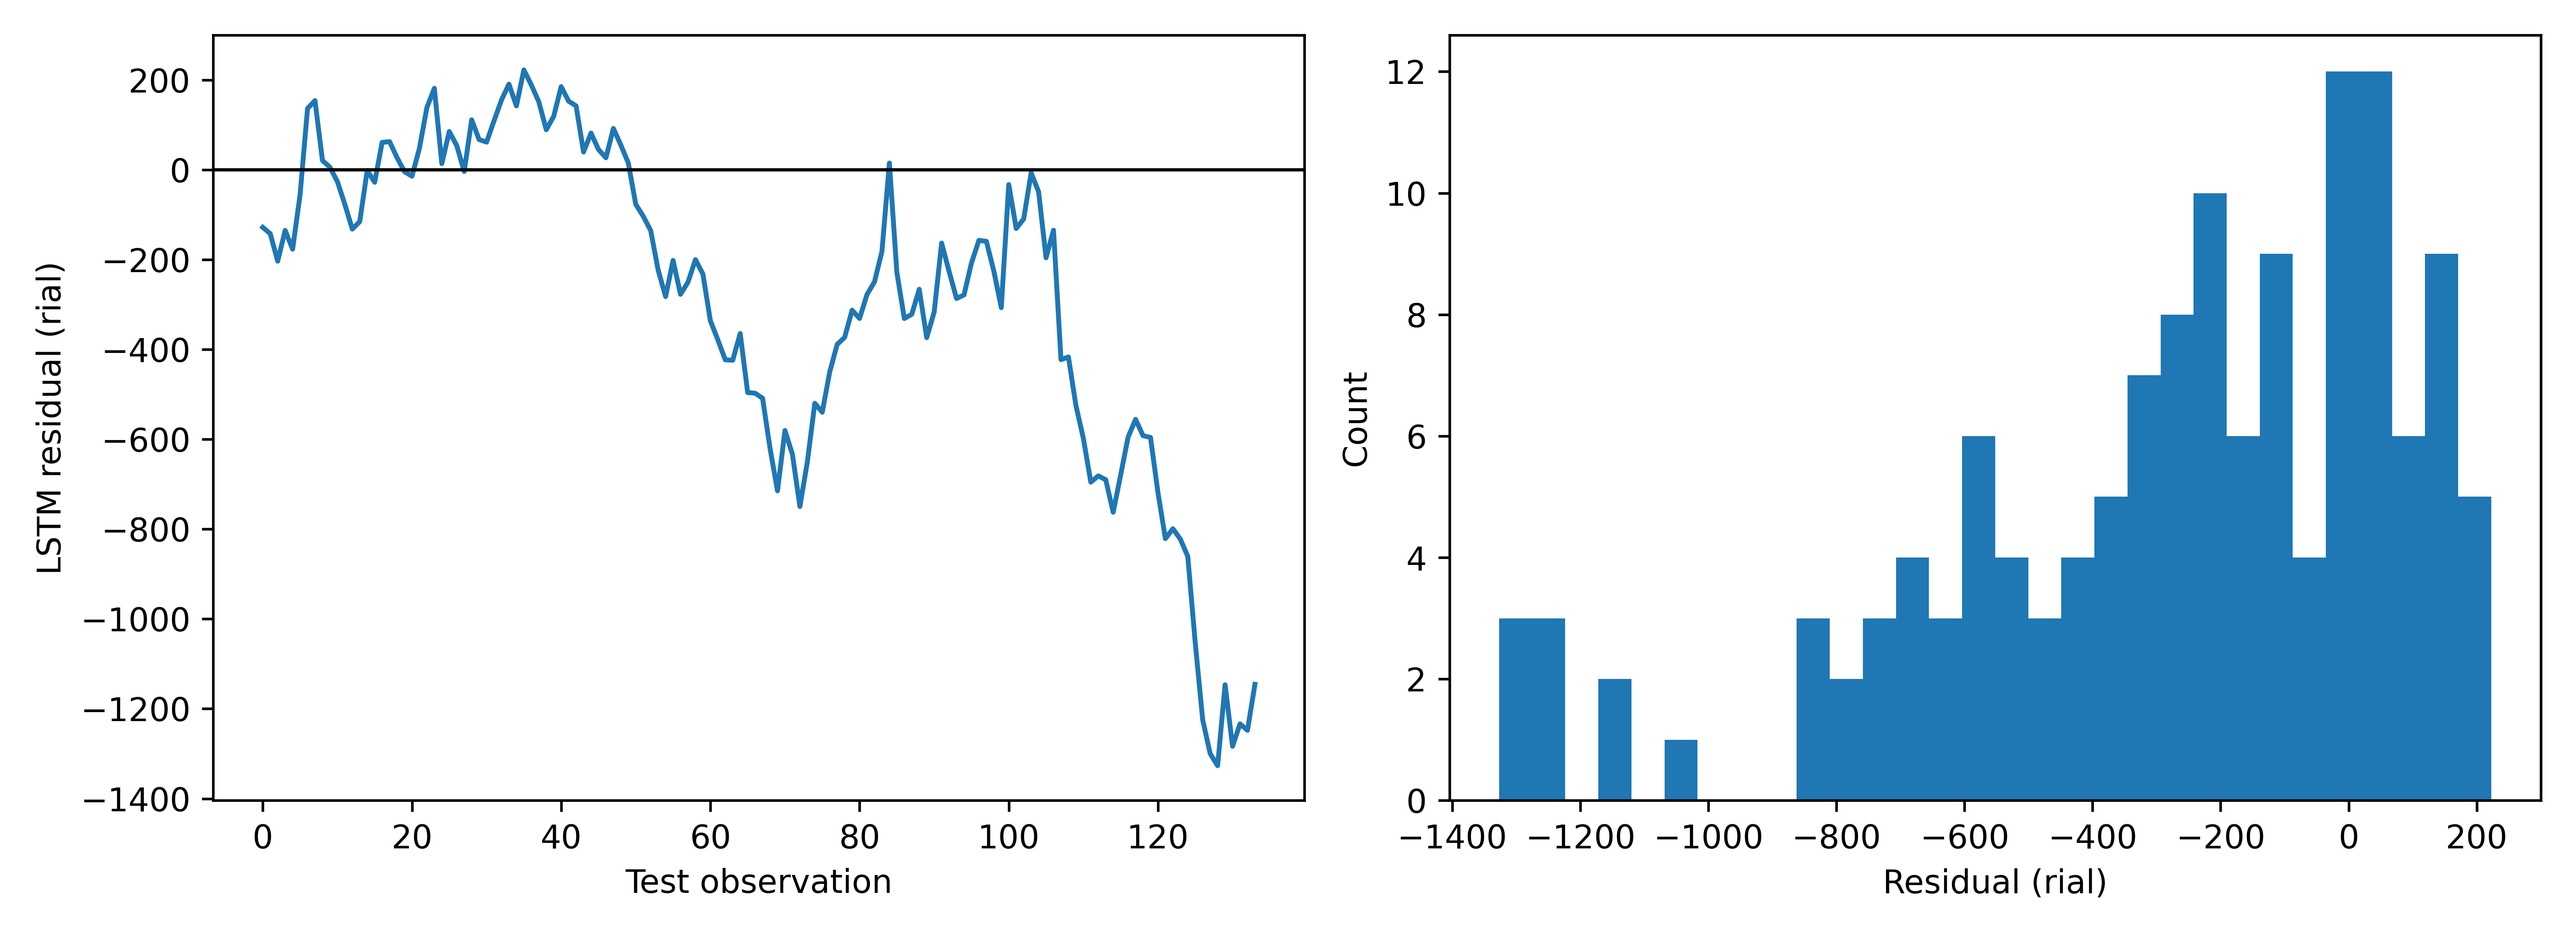

# MarketForecast research report

## Objective and data
Predict فولاد's next observed traded session's adjusted official closing price after the current session.
Source: TSETMC via user-supplied pytse-client CSV exports. Period: 2021-09-26 to 2026-09-26.
Retrieved: Not recorded by source exporter. Instrument IDs: 46348559193224090.
Prices are rials; volume is shares. The raw source, normalized raw CSV, and SHA-256 checksums are frozen.
Official closing price is pClosing (FinPy Final); pDrCotVal (FinPy Close) is last trade.

## Cleaning and corporate actions
1038 raw rows; 1037 valid rows;
1 quarantined rows. Reasons: {'nonpositive_price': 1, 'invalid_candle': 1}.
Adjustment basis: Verified complete export chain, including quarantined missing-open session.
Quarantined candles are excluded; all input windows and their targets must be consecutive source sessions.
User CSV imports preserve original export bytes; HTTP response bodies and original retrieval/package
version metadata are unavailable when the exporter did not record them (see snapshot manifest).
No synthetic holiday/suspension candles or price interpolation. Large raw moves are flagged, not automatically removed.
Backward adjustment multiplies price fields by the reverse cumulative product of next-session
previous official close / current official close. Final factor = 1. Volume is unchanged.
This uses future corporate-action information: the study is retrospective on a frozen adjustment basis,
not a point-in-time backtest, forecast of unadjusted transaction prices, or evidence of achievable profit.

## Features and chronological preparation
1004 usable feature rows after 33 warm-up/nonfinite exclusions.
Features include OHLCV, lags, returns, SMA/EMA 5/10/20, volatility/extrema, Wilder RSI-14 and ATR-14,
MACD 12/26/9, Bollinger 20, volume ratios, interaction and calendar variables.
All rolling calculations use current/past observations only, on the fixed adjusted series.
Common eligible target dates are shared by all window lengths. Split fractions are
70% / 15% / 15%.
Cutoffs: {'train': {'first_target': '2022-02-07', 'last_target': '2024-11-06', 'samples': 618}, 'validation': {'first_target': '2024-11-09', 'last_target': '2025-06-08', 'samples': 132}, 'test': {'first_target': '2025-06-09', 'last_target': '2026-09-26', 'samples': 134}}.
Input and target StandardScalers are fitted independently on training inputs/targets only.

## Models and selection
One LSTM layer; dropout 0.2; dense linear output; Adam 0.001; MSE loss;
batch size 32; at most 100 epochs; early stopping patience 10.
Validation-only search: lengths [10, 30, 60], units [32, 64].
Selected: length 60, units 64, validation RMSE 324.054 adjusted rials.
Seed: 42. Ridge alpha is selected on validation. OHLCV ablation uses the selected architecture.
The test set is evaluated only after all selections; no train-plus-validation refit.

## Held-out results
MAE and RMSE are adjusted rials; MAPE is percent. MSE is also recorded in test_metrics.json.

| Model | MAE | RMSE | MAPE (%) |
|---|---:|---:|---:|
| lstm | 335.574 | 467.071 | 11.756 |
| persistence | 52.125 | 60.801 | 1.966 |
| ridge | 187.942 | 261.746 | 7.000 |
| ohlcv_lstm | 283.325 | 390.777 | 9.900 |

LSTM test RMSE improvement against persistence: -668.20% (negative means worse).
The result is descriptive; performance is not guaranteed on later market regimes.
Five years of one stock provide limited independent samples, and overlapping windows are correlated.
The study does not include transaction costs, tradability/queues, or a trading strategy.

## Reproducibility and artifacts
The environment, configuration, snapshot checksums, feature order, split dates, scalers,
candidate logs, selected .keras/.h5 models, sequences, predictions, metrics, and figures are saved together.
Both selected saved model formats were reloaded and verified against exported predictions.
See loss_selected_lstm.png, loss_ohlcv_lstm.png, test_forecasts.png, and residuals.png.


In [7]:
from marketforecast.workflow import verify_run
print(verify_run(OUTPUT))
from IPython.display import Image, Markdown, display
for filename in ["loss_selected_lstm.png", "loss_ohlcv_lstm.png", "test_forecasts.png", "residuals.png"]:
    display(Image(filename=str(OUTPUT / filename)))
display(Markdown((OUTPUT / "report.md").read_text(encoding="utf-8")))


## Export
The archive includes snapshot, CSVs, sequences, scalers, checkpoints, models, configuration/environment,
predictions, metrics, figures, and the English report. Drive retains original files.


In [8]:
from marketforecast.workflow import export_bundle
BUNDLE = export_bundle(ROOT, OUTPUT)
print("Saved archive:", BUNDLE)
# Optional browser download (especially without Drive):
# from google.colab import files
# files.download(str(BUNDLE))


Saved archive: /content/drive/MyDrive/MarketForecast/artifacts/marketforecast_0fae8c8d8bf0.zip
